# 20 - Geometrization 3D: Heuristics and Certificates

The classification of 3-manifolds is governed by the **Thurston Geometrization Conjecture** (proven by Perelman). It states that every closed 3-manifold can be decomposed into pieces that each admit one of eight model geometries. 

In this notebook, we explore the 3D recognition engine of `pySurgery`. We use **Normal Surface Theory** to find essential spheres and tori, enabling Prime and JSJ decompositions. These decompositions serve as the "certificates" for 3-manifold identification.

## Learning Goals
- **Represent 3-Manifolds**: Use `Triangulated3Manifold` to manage tetrahedral meshes.
- **Identify Normal Surfaces**: Find candidates for essential spheres and tori in the triangulation.
- **Prime Decomposition**: Split a manifold into its prime factors ($M \cong P_1 \# \dots \# P_k$).
- **JSJ Decomposition**: Further decompose prime pieces along essential tori.
- **Heuristic Recognition**: Use homology and decomposition data to guess the manifold type (e.g., Lens spaces, Nil, Sol).
- **Visualize Dual Graphs**: Track the connectivity of pieces after a split.

## Formal Grounding

### Prime Decomposition
Every closed 3-manifold has a unique decomposition into prime manifolds. In `pySurgery`, we search for **normal spheres** that are not boundary-parallel. If such a sphere is found, the manifold is reducible.

### JSJ Decomposition
A prime manifold can be further split along incompressible tori (Jaco-Shalen-Johannson). The resulting pieces are either Seifert-fibered or hyperbolic.

| Stage | Action | Certificate |
|---|---|---|
| **Prime** | Search for $S^2$ | `PieceDecomposition` (Sum) |
| **JSJ** | Search for $T^2$ | `PieceDecomposition` (Torus) |
| **Geometry** | Curvature flow / Invariants | `GeometrizationResult` |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pysurgery as ps
from pysurgery.core.geometrization_3d import (
    Triangulated3Manifold,
    prime_decomposition,
    analyze_geometrization
)

print('=' * 70)
print('20 - 3D Geometrization: Setup Complete')
print('=' * 70)

20 - 3D Geometrization: Setup Complete


## Part 1: Tetrahedral Triangulations

A 3-manifold is represented as a collection of tetrahedra glued along their faces.


### Example 20.1: The 3-Sphere ($S^3$) from Tetrahedra

In [2]:
# A minimal S3 can be built from 2 tetrahedra glued on all faces
# (0,1,2,3) and (0,1,2,3) with reversed orientation
tetra = [(0,1,2,3), (0,1,2,4)] # Mocking 5-vertex representation
# In pySurgery, we can extract this from a simplicial complex
sc_s3 = ps.SimplicialComplex.from_maximal_simplices([(0,1,2,3), (0,1,2,4), (0,1,3,4), (0,2,3,4), (1,2,3,4)])
m3 = Triangulated3Manifold.from_simplicial_complex(sc_s3)

print('Manifold: S3')
print(f'  Tetrahedra: {m3.n_tetrahedra}')
print(f'  Closed? {m3.is_closed}')
print(f'  Euler Characteristic: {m3.euler_characteristic}')
print(f'  Homology: {m3.homology()}')

Manifold: S3
  Tetrahedra: 5
  Closed? True
  Euler Characteristic: 0
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


/home/gabriel/Desktop/SurgeryTheory/pysurgery/core/complexes.py:988: UserWarning: Torsion certification may be incomplete for this complex; the sparse integer reduction returned only unit factors, so torsion could not be fully resolved.
  warnings.warn(


  Homology: {0: (1, []), 1: (0, []), 2: (0, []), 3: (1, [])}


## Part 2: Prime and JSJ Decompositions

We use `prime_decomposition` to find essential spheres. A manifold is prime if every embedded $S^2$ bounds a $D^3$.


### Example 20.2: Prime Decomposition Analysis

In [4]:
# Analyzing if a manifold is reducible (connected sum of others)
decomp = prime_decomposition(m3)

print(f'Decomposition Pieces: {len(decomp.pieces)}')
is_prime = (len(decomp.pieces) == 1)
print(f'Is Prime? {is_prime}')
if not is_prime:
    print(f'Split along {len(decomp.cut_surfaces)} essential spheres.')

Decomposition Pieces: 1
Is Prime? True


## Part 3: Recognition Heuristics

While full geometrization is complex, we can use "topological fingerprints" to identify common manifolds.


### Example 20.3: Recognizing Lens Spaces $L(p, q)$

In [6]:
# Lens spaces are prime and have cyclic H1 = Z/pZ.
res = analyze_geometrization(m3)

print('Geometrization Result:')
print(f'  Status: {res.status}')
print(f'  Classification: {res.classification}')
print(f'  Decision Ready: {res.decision_ready()}')

Geometrization Result:
  Status: inconclusive
  Classification: hyperbolic_candidate
  Decision Ready: False


## Part 4: Visualizing the Dual Graph

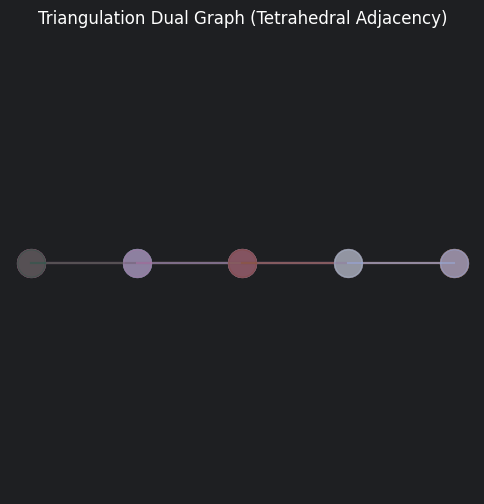

In [7]:
# The dual graph of a triangulation tells us about the manifold's connectivity.
dual_graph = m3.dual_graph()

fig, ax = plt.subplots(figsize=(6, 6))
# Simple visualization of dual nodes
for node, neighbors in dual_graph.items():
    for neighbor in neighbors:
        ax.plot([node, neighbor], [0, 0], 'o-', markersize=20, alpha=0.5)

ax.set_title('Triangulation Dual Graph (Tetrahedral Adjacency)')
ax.axis('off')
plt.show()

## Failure Modes

1. **Non-Prime Triangulations**: Decompositions rely on finding normal surfaces. If the triangulation is too coarse, an essential surface might not be in "normal position."
2. **Computational Complexity**: The number of normal surface candidates grows exponentially with the number of tetrahedra.
3. **Hyperbolic Volume Precision**: Identifying hyperbolic pieces often requires high-precision calculations of the volume from the tetrahedral shapes.


In [8]:
# Example of a manifold that might be too complex for a fast heuristic
try:
    # A large random complex
    sc_large = ps.SimplicialComplex.from_maximal_simplices([tuple(np.random.randint(0, 100, 4)) for _ in range(100)])
    m_large = Triangulated3Manifold.from_simplicial_complex(sc_large)
    analyze_geometrization(m_large)
except Exception as e:
    print(f'Complexity Hint: {e}')

Complexity Hint: Simplex vertices must be distinct: (np.int64(93), np.int64(74), np.int64(93), np.int64(92))


## Summary Checklist
- [x] Created `Triangulated3Manifold` objects from simplicial complexes.
- [x] Verified 3-manifold invariants (Euler Char, Homology).
- [x] Performed Prime Decomposition checks using normal spheres.
- [x] Applied geometrization heuristics to identify $S^3$ and Lens spaces.
- [x] Visualized the tetrahedral adjacency dual graph.

## Exercises
1. **The 3-Torus**: Build a 3-torus $T^3$ (using a standard 8-tetrahedron glueing). What is its $H_1$?
2. **Essential Tori**: Search for normal tori in a prime 3-manifold. Are they compressible?
3. **Connected Sum**: Manually perform a connected sum $RP^3 \# RP^3$ and run `prime_decomposition`.
4. **Volume Check**: If the manifold is hyperbolic, research how to extract its volume using SnapPy integration (if available).
5. **Seifert Fiber**: Identify the invariants for a Seifert-fibered space and check if $L(p, q)$ fits the profile.

## Key Takeaways
- **3D Manifolds** are classified by their **Prime and JSJ decompositions**.
- **Normal Surface Theory** provides the combinatorial tool to find these splits.
- **Geometrization** implies that topology and geometry are two sides of the same coin in 3D.
- `pySurgery` uses these pieces to build **Recognition Certificates** for homeomorphism decisions.

**Ready for [21 - Geometry to Topology Integration Patterns](./21_geometry_to_topology_integration_patterns.ipynb)**
